In [1]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

In [7]:
df_bow = pd.read_csv("../dados/bow.csv")
df_tfidf = pd.read_csv("../dados/tfidf.csv")

print(f"BoW:    {df_bow.shape}")
print(f"TF-IDF: {df_tfidf.shape}")
df_bow.iloc[0]

BoW:    (1101, 466)
TF-IDF: (1101, 465)


Marca                                                 Jorge Bischoff
Cor                                                           Marrom
Vendedor                                                      Dafiti
Produto                Bota Feminina Jorge Bischoff Cano Alto Marrom
Tags               Calçados,Calçados Femininos,Botas,Bota Montari...
                                         ...                        
bow_white                                                          0
bow_wm                                                             0
bow_xl                                                             0
bow_ziper                                                          0
palavras_unicas                                                    7
Name: 0, Length: 466, dtype: object

In [9]:
import re

tags_unicas = (
    df_bow['Tags']
    .dropna()
    .apply(lambda x: re.split(r'\s*,\s*', x))  # separa por vírgula ignorando espaços
    .explode()
    .str.strip()
    .unique()
    .tolist()
)

print(tags_unicas)

['Calçados', 'Calçados Femininos', 'Botas', 'Bota Montaria e Cano Longo', 'Bota Cano Curto', 'Tênis', 'Tênis Casual', 'Slip On', 'Esporte', 'Esporte Feminino', 'Tênis Performance', 'Sandálias', 'Chinelos', 'Sapatilhas', 'Sapatilha Bico Fino', 'Tamanco', 'Scarpin', 'Rasteirinhas', 'Sandália Salto Grosso', 'Sapatilha Bico Redondo', 'Mocassim', 'Papete', 'Sandália Salto Fino', 'Calçados Masculinos', 'Sandália Anabela', 'Alpargatas', 'Bota Cano Médio', 'Esporte Masculino', 'Sapatos', 'Scarpins', 'Coturno e Biker', 'Slippers', 'Sandália Plataforma', 'Tênis performance']


In [17]:
# cria dummies
dummies = df_bow['Tags'].str.get_dummies(sep=',')

# frequência de cada tag
freq = dummies.sum()

# percentual de ocorrência
freq_relativa = freq / len(df_bow)

# remover tags muito comuns
# exemplo: remover tags presentes em mais de 80% dos produtos
tags_relevantes = freq_relativa[freq_relativa < 0.80].index

# filtra apenas as relevantes
dummies_filtrado = dummies[tags_relevantes]

print(dummies_filtrado.columns.tolist())

['Alpargatas', 'Bota Cano Curto', 'Bota Cano Médio', 'Bota Montaria e Cano Longo', 'Botas', 'Calçados Masculinos', 'Chinelos', 'Coturno e Biker', 'Esporte', 'Esporte Feminino', 'Esporte Masculino', 'Mocassim', 'Papete', 'Rasteirinhas', 'Sandália Anabela', 'Sandália Plataforma', 'Sandália Salto Fino', 'Sandália Salto Grosso', 'Sandálias', 'Sapatilha Bico Fino', 'Sapatilha Bico Redondo', 'Sapatilhas', 'Sapatos', 'Scarpin', 'Scarpins', 'Slip On', 'Slippers', 'Tamanco', 'Tênis', 'Tênis Casual', 'Tênis Performance', 'Tênis performance']


In [11]:
print(dummies)

      Alpargatas  Bota Cano Curto  Bota Cano Médio  \
0              0                0                0   
1              0                1                0   
2              0                1                0   
3              0                0                0   
4              0                0                0   
...          ...              ...              ...   
1096           0                0                0   
1097           0                0                0   
1098           0                0                0   
1099           0                0                0   
1100           0                0                0   

      Bota Montaria e Cano Longo  Botas  Calçados  Calçados Femininos  \
0                              1      1         1                   1   
1                              0      1         1                   1   
2                              0      1         1                   1   
3                              0      0         1          

In [18]:
df_final = pd.concat([df_bow, dummies_filtrado], axis=1)

In [19]:
colunas_bow = [c for c in df_final.columns if c.startswith("bow_")]
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]

X_bow = df_bow[colunas_bow].values
X_tfidf = df_tfidf[colunas_tfidf].values

titulos = df_bow["Produto"].tolist()

print(f"X_bow:   {X_bow.shape}")
print(f"X_tfidf: {X_tfidf.shape}")

X_bow:   (1101, 456)
X_tfidf: (1101, 456)


In [29]:
# mexer com os hiperparametros

perplexity = 50
random_state = 42

tsne_bow = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_bow = tsne_bow.fit_transform(X_bow)

tsne_tfidf = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_tfidf = tsne_tfidf.fit_transform(X_tfidf)

print("embed_bow:  ", embed_bow.shape)
print("embed_tfidf:", embed_tfidf.shape)

embed_bow:   (1101, 2)
embed_tfidf: (1101, 2)


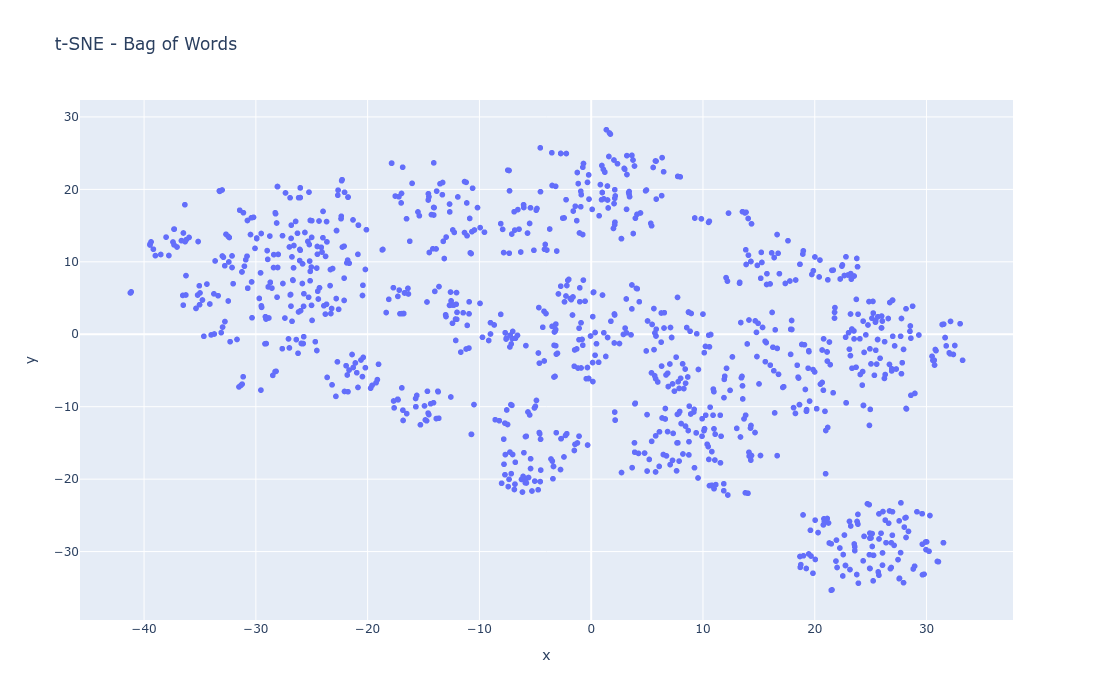

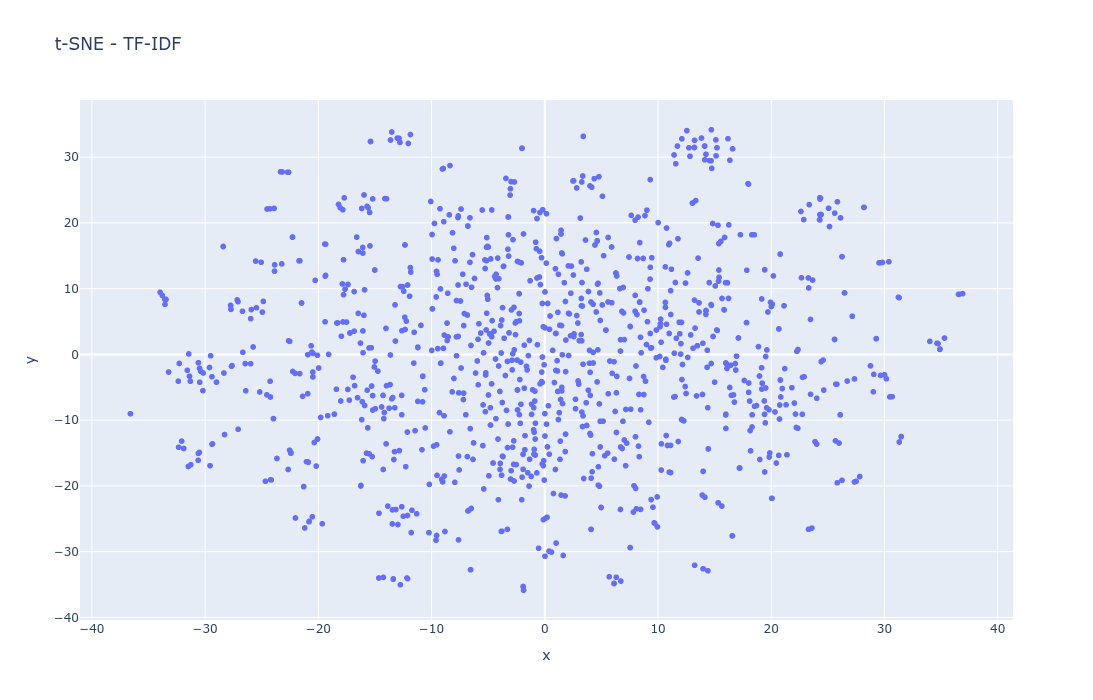

In [30]:
def plotar(embed, nome):
    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "Produto": df_bow["Produto"],
        "Preço": df_bow["Preço Original"],
    })
    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        hover_data={"indice": True, "Produto": True, "Preço": True, "x": False, "y": False},
        title=f"t-SNE - {nome}",
        width=700,
        height=700,
    )
    fig.write_html(nome+".html")
    fig.show()


plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")

32 tags mantidas


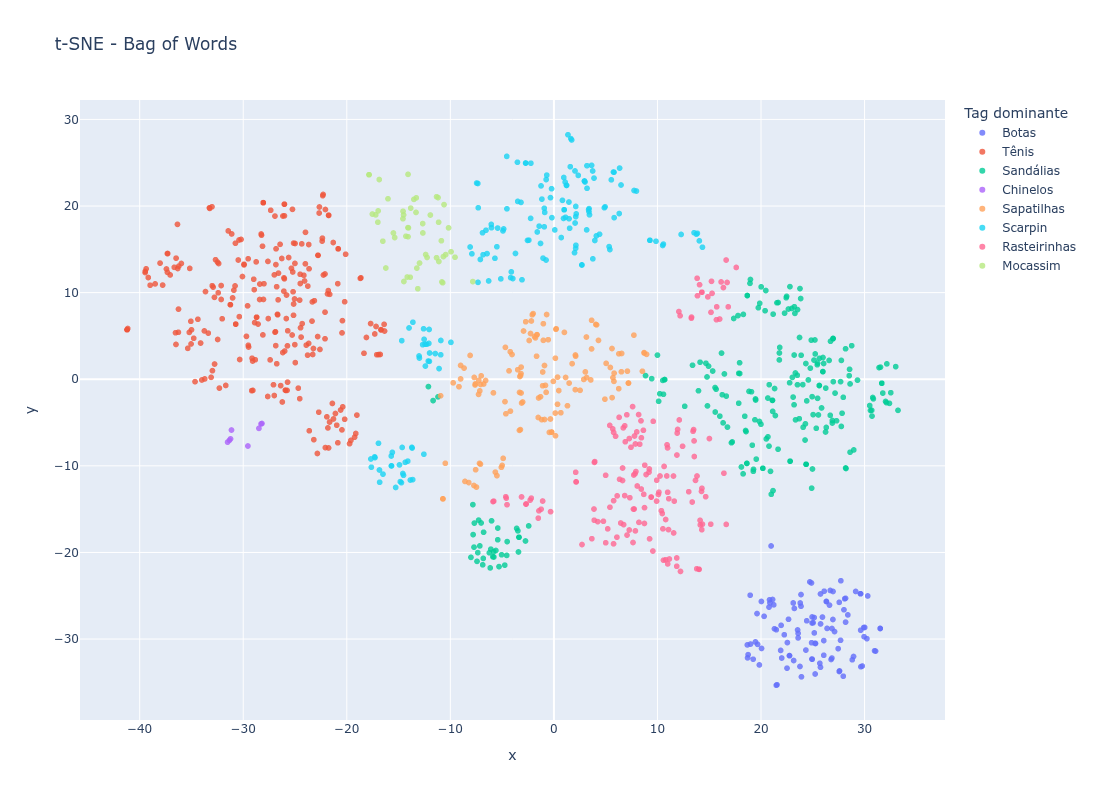

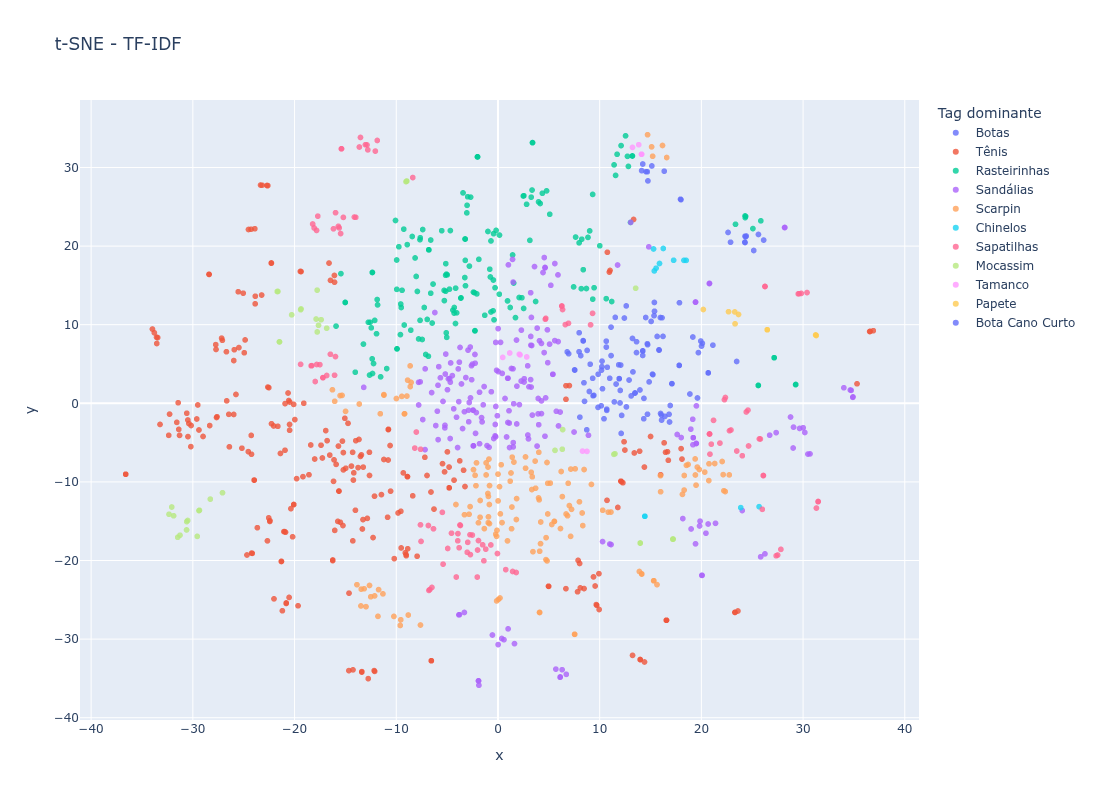

In [31]:
import pandas as pd
import plotly.express as px
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import re

# ---------------------------------------------------
# REMOVE TAGS MUITO FREQUENTES
# ---------------------------------------------------

# cria matriz dummy
dummies = df_bow['Tags'].str.get_dummies(sep=',')

# frequência relativa das tags
freq_relativa = dummies.sum() / len(df_bow)

# mantém apenas tags menos frequentes
# ajuste o threshold se quiser
TRESHOLD = 0.80

tags_validas = freq_relativa[
    freq_relativa < TRESHOLD
].index.tolist()

print(f"{len(tags_validas)} tags mantidas")


# ---------------------------------------------------
# TAG DOMINANTE DA VIZINHANÇA
# ---------------------------------------------------

def tag_mais_comum_vizinhos(
    embed,
    tags_series,
    tags_validas,
    k=10
):

    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(embed)

    _, indices = nn.kneighbors(embed)

    tags_dominantes = []

    for vizinhos in indices:

        todas_tags = []

        for idx in vizinhos:

            tags = re.split(
                r'\s*,\s*',
                str(tags_series.iloc[idx])
            )

            # filtra tags comuns
            tags_filtradas = [
                t for t in tags
                if t in tags_validas
            ]

            todas_tags.extend(tags_filtradas)

        # fallback caso todas tenham sido removidas
        if len(todas_tags) == 0:
            tags_dominantes.append("Sem categoria")
            continue

        tag = Counter(todas_tags).most_common(1)[0][0]

        tags_dominantes.append(tag)

    return tags_dominantes


# ---------------------------------------------------
# PLOT
# ---------------------------------------------------

def plotar(embed, nome, k=10):

    tags_cluster = tag_mais_comum_vizinhos(
        embed=embed,
        tags_series=df_bow["Tags"],
        tags_validas=tags_validas,
        k=k
    )

    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "Produto": df_bow["Produto"],
        "Preço": df_bow["Preço Original"],
        "Tag dominante": tags_cluster
    })

    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        color="Tag dominante",
        hover_data={
            "indice": True,
            "Produto": True,
            "Preço": True,
            "Tag dominante": True,
            "x": False,
            "y": False
        },
        title=f"t-SNE - {nome}",
        width=1000,
        height=800,
    )

    fig.update_traces(
        marker=dict(size=6, opacity=0.8)
    )

    fig.write_html(nome + ".html")

    fig.show()


# ---------------------------------------------------
# EXECUÇÃO
# ---------------------------------------------------

plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")

In [10]:
df_bow.columns

Index(['Marca', 'Cor', 'Vendedor', 'Produto', 'Tags', 'Preço Original',
       'Preço Pix', 'Preço Parcelado', 'Quantidade de Parcelas', 'bow_aberta',
       ...
       'bow_vinho', 'bow_vintage', 'bow_vizzano', 'bow_warm', 'bow_wh',
       'bow_white', 'bow_wm', 'bow_xl', 'bow_ziper', 'palavras_unicas'],
      dtype='object', length=466)

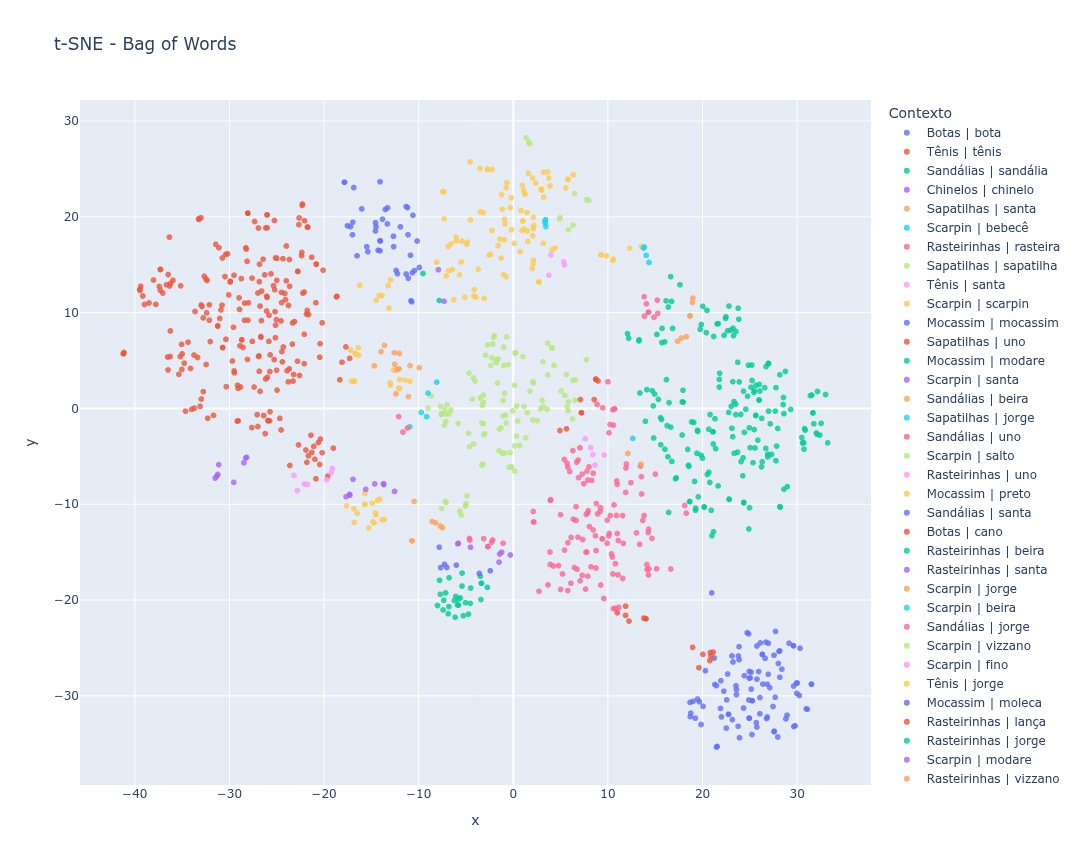

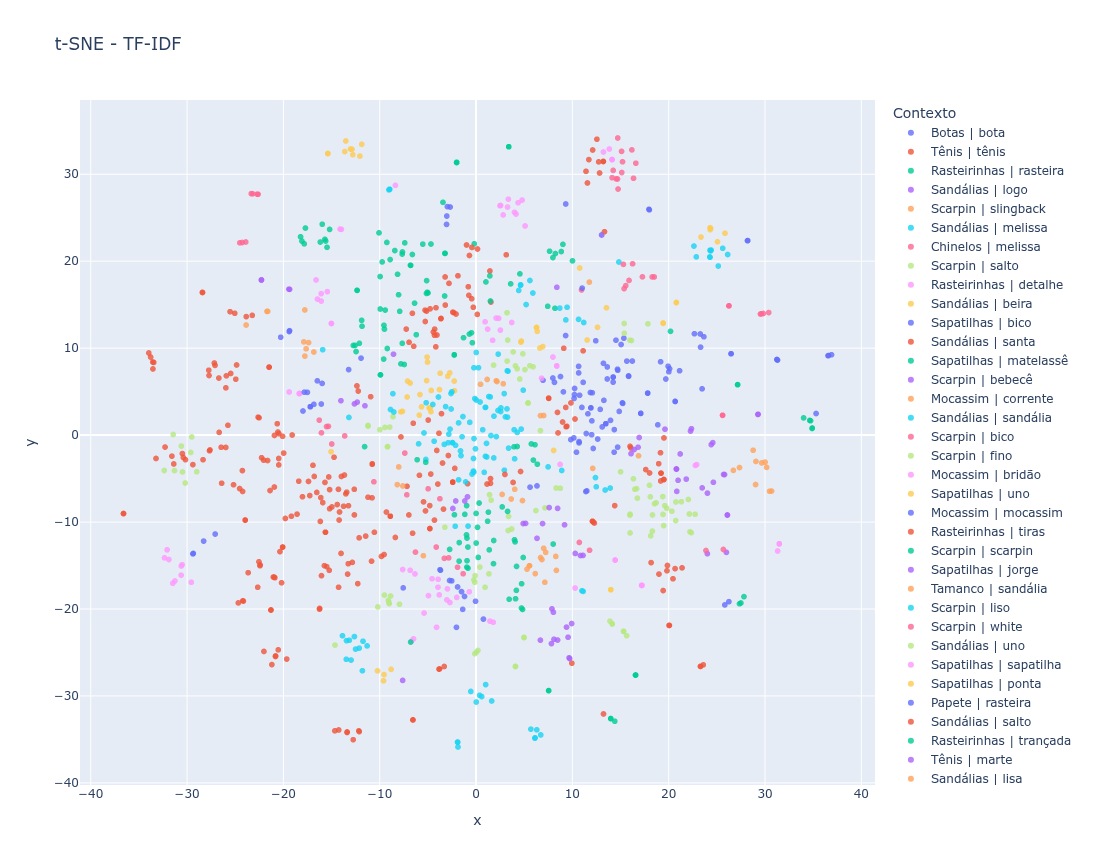

In [33]:
import pandas as pd
import plotly.express as px
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import re

# ---------------------------------------------------
# STOPWORDS
# ---------------------------------------------------

stopwords = {
    "de", "da", "do", "das", "dos",
    "para", "com", "sem", "em",
    "e", "a", "o",
    "feminino", "feminina",
    "masculino", "masculina", "via", "off"
}

# ---------------------------------------------------
# REMOVE TAGS MUITO FREQUENTES
# ---------------------------------------------------

dummies = df_bow['Tags'].str.get_dummies(sep=',')

freq_relativa = dummies.sum() / len(df_bow)

THRESHOLD = 0.80

tags_validas = freq_relativa[
    freq_relativa < THRESHOLD
].index.tolist()


# ---------------------------------------------------
# EXTRAI PALAVRAS RELEVANTES
# ---------------------------------------------------

def extrair_palavras(texto):

    palavras = re.findall(
        r'\b[a-zà-úA-ZÀ-Ú]+\b',
        str(texto).lower()
    )

    palavras = [
        p for p in palavras
        if p not in stopwords
        and len(p) > 2
    ]

    return palavras


# ---------------------------------------------------
# TAG + PALAVRA DOMINANTE
# ---------------------------------------------------

def contexto_dominante_vizinhos(
    embed,
    tags_series,
    produto_series,
    tags_validas,
    k=10
):

    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(embed)

    _, indices = nn.kneighbors(embed)

    labels = []

    for vizinhos in indices:

        todas_tags = []
        todas_palavras = []

        for idx in vizinhos:

            # -------------------------
            # TAGS
            # -------------------------

            tags = re.split(
                r'\s*,\s*',
                str(tags_series.iloc[idx])
            )

            tags = [
                t for t in tags
                if t in tags_validas
            ]

            todas_tags.extend(tags)

            # -------------------------
            # PRODUTO
            # -------------------------

            palavras = extrair_palavras(
                produto_series.iloc[idx]
            )

            todas_palavras.extend(palavras)

        # -------------------------
        # TAG dominante
        # -------------------------

        tag = (
            Counter(todas_tags).most_common(1)[0][0]
            if len(todas_tags) > 0
            else "SemTag"
        )

        # -------------------------
        # Palavra dominante
        # -------------------------

        palavra = (
            Counter(todas_palavras).most_common(1)[0][0]
            if len(todas_palavras) > 0
            else "SemPalavra"
        )

        # label final
        label = f"{tag} | {palavra}"

        labels.append(label)

    return labels


# ---------------------------------------------------
# PLOT
# ---------------------------------------------------

def plotar(embed, nome, k=10):

    labels = contexto_dominante_vizinhos(
        embed=embed,
        tags_series=df_bow["Tags"],
        produto_series=df_bow["Produto"],
        tags_validas=tags_validas,
        k=k
    )

    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "Produto": df_bow["Produto"],
        "Preço": df_bow["Preço Original"],
        "Contexto": labels
    })

    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        color="Contexto",
        hover_data={
            "indice": True,
            "Produto": True,
            "Preço": True,
            "Contexto": True,
            "x": False,
            "y": False
        },
        title=f"t-SNE - {nome}",
        width=1100,
        height=850,
    )

    fig.update_traces(
        marker=dict(
            size=6,
            opacity=0.8
        )
    )

    fig.write_html(nome + ".html")

    fig.show()


# ---------------------------------------------------
# EXECUÇÃO
# ---------------------------------------------------

plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")

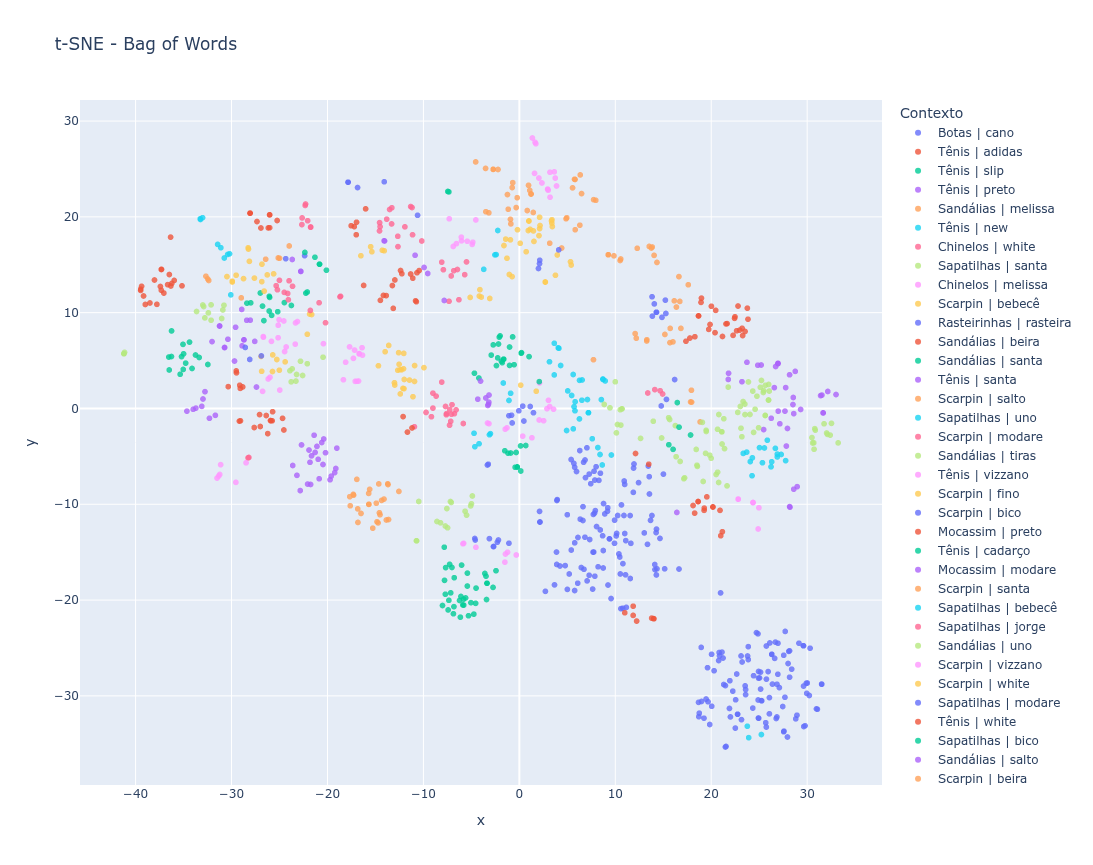

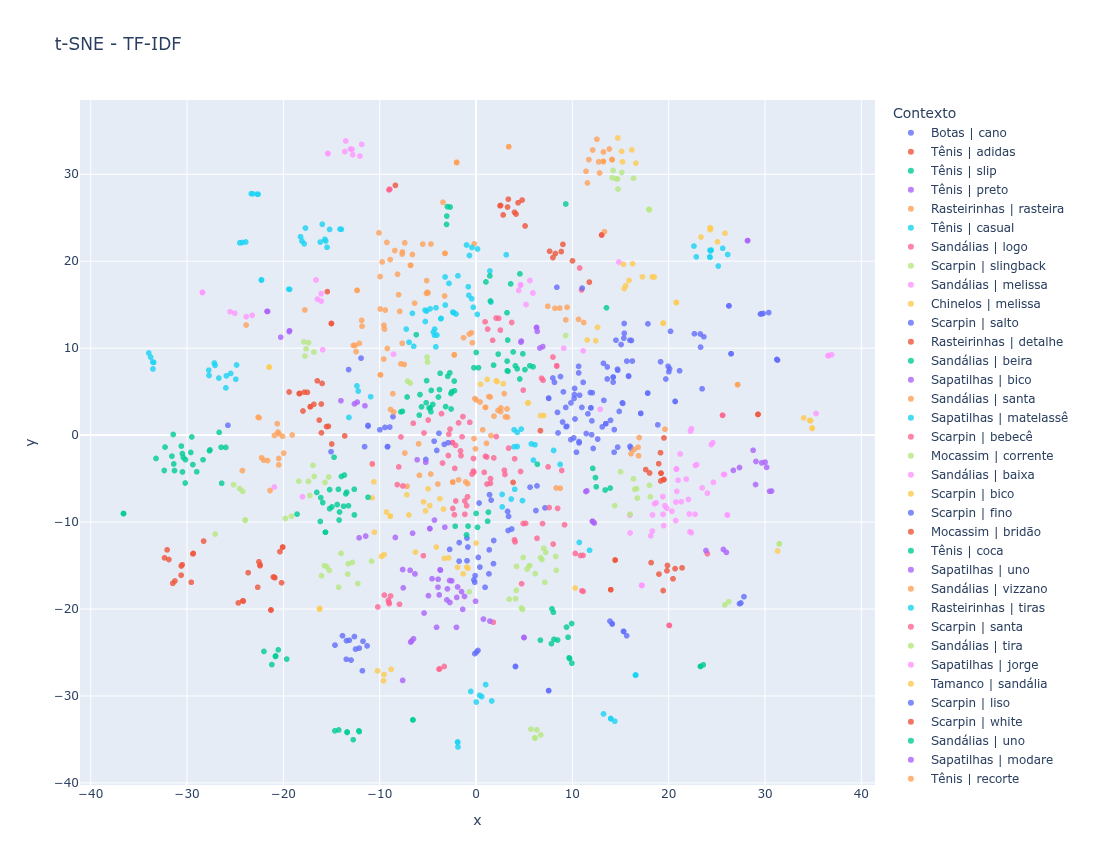

In [34]:
import pandas as pd
import plotly.express as px
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import re

# ---------------------------------------------------
# STOPWORDS
# ---------------------------------------------------

stopwords = {
    "de", "da", "do", "das", "dos",
    "para", "com", "sem", "em",
    "e", "a", "o",
    "feminino", "feminina",
    "masculino", "masculina",
    "via", "off"
}

# ---------------------------------------------------
# REMOVE TAGS MUITO FREQUENTES
# ---------------------------------------------------

dummies = df_bow['Tags'].str.get_dummies(sep=',')

freq_relativa = dummies.sum() / len(df_bow)

THRESHOLD = 0.80

tags_validas = freq_relativa[
    freq_relativa < THRESHOLD
].index.tolist()

# ---------------------------------------------------
# EXTRAI PALAVRAS RELEVANTES
# ---------------------------------------------------

def extrair_palavras(texto):

    palavras = re.findall(
        r'\b[a-zà-úA-ZÀ-Ú]+\b',
        str(texto).lower()
    )

    palavras = [
        p for p in palavras
        if p not in stopwords
        and len(p) > 2
    ]

    return palavras


# ---------------------------------------------------
# TAG + PALAVRA DOMINANTE
# ---------------------------------------------------

def contexto_dominante_vizinhos(
    embed,
    tags_series,
    produto_series,
    tags_validas,
    k=10
):

    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(embed)

    _, indices = nn.kneighbors(embed)

    labels = []

    for vizinhos in indices:

        todas_tags = []
        todas_palavras = []

        for idx in vizinhos:

            # -------------------------
            # TAGS
            # -------------------------

            tags = re.split(
                r'\s*,\s*',
                str(tags_series.iloc[idx])
            )

            tags = [
                t for t in tags
                if t in tags_validas
            ]

            todas_tags.extend(tags)

            # -------------------------
            # PRODUTO
            # -------------------------

            palavras = extrair_palavras(
                produto_series.iloc[idx]
            )

            todas_palavras.extend(palavras)

        # -------------------------
        # TAG dominante
        # -------------------------

        tag = (
            Counter(todas_tags).most_common(1)[0][0]
            if len(todas_tags) > 0
            else "SemTag"
        )

        # -------------------------
        # Palavra dominante
        # -------------------------

        if len(todas_palavras) > 0:

            contagem_palavras = Counter(todas_palavras)

            palavra = "SemPalavra"

            for p, _ in contagem_palavras.most_common():

                # normalização
                p_norm = p.lower().strip()
                tag_norm = tag.lower().strip()

                # impede repetir tag
                if (
                    p_norm != tag_norm
                    and p_norm not in tag_norm
                    and tag_norm not in p_norm
                ):
                    palavra = p
                    break

        else:
            palavra = "SemPalavra"

        # -------------------------
        # label final
        # -------------------------

        label = f"{tag} | {palavra}"

        labels.append(label)

    return labels


# ---------------------------------------------------
# PLOT
# ---------------------------------------------------

def plotar(embed, nome, k=10):

    labels = contexto_dominante_vizinhos(
        embed=embed,
        tags_series=df_bow["Tags"],
        produto_series=df_bow["Produto"],
        tags_validas=tags_validas,
        k=k
    )

    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "Produto": df_bow["Produto"],
        "Preço": df_bow["Preço Original"],
        "Contexto": labels
    })

    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        color="Contexto",
        hover_data={
            "indice": True,
            "Produto": True,
            "Preço": True,
            "Contexto": True,
            "x": False,
            "y": False
        },
        title=f"t-SNE - {nome}",
        width=1100,
        height=850,
    )

    fig.update_traces(
        marker=dict(
            size=6,
            opacity=0.8
        )
    )

    fig.write_html(nome + ".html")

    fig.show()


# ---------------------------------------------------
# EXECUÇÃO
# ---------------------------------------------------

plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")